# Experiment 4: Credit Risk Assessment Using Multiple Linear Regression

### Aim

To develop and evaluate a Multiple Linear Regression model that predicts an applicant's credit score using demographic and historical financial attributes.


## Dataset Description

The dataset contains historical financial information of applicants. The target variable is **Credit_Score**, which is a continuous numerical value.

The independent variables used for prediction are:

* Age
* Annual Income
* Debt-to-Income Ratio
* Late Payments in the Last 12 Months
* Credit History Years
* Credit Utilization Ratio
* Existing Loans
* Employment Years

`Applicant_ID` is removed because it is only an identifier and does not contribute to prediction.


## Step 1: Import Required Libraries

The required Python libraries are imported for data handling, visualization, model building, preprocessing, and evaluation.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



## Step 2: Load the Dataset

The CSV dataset is loaded into a pandas DataFrame for further analysis and model development.


In [3]:
df=pd.read_csv("cred_risk.csv")
print(df.head())

   Applicant_ID  Age  Annual_Income_INR  Debt_to_Income_Ratio  \
0             1   61             576000                  0.07   
1             2   26            1536000                  0.07   
2             3   56             840000                  0.50   
3             4   31            1536000                  0.26   
4             5   26            1404000                  0.11   

   Late_Payments_12M  Credit_History_Years  Credit_Utilization_Ratio  \
0                  4                     8                      0.24   
1                  1                     4                      0.24   
2                  8                    14                      0.23   
3                  2                     4                      0.91   
4                  5                     5                      0.77   

   Existing_Loans  Employment_Years  Credit_Score  
0               5                 3           341  
1               4                 0           484  
2               4   

## Step 3: Inspect the Dataset

The dataset is inspected to understand its dimensions, data types, descriptive statistics, missing values, and duplicate records.


In [4]:
print("Shape of dataset:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of dataset: (200, 10)

Data Types:
Applicant_ID                  int64
Age                           int64
Annual_Income_INR             int64
Debt_to_Income_Ratio        float64
Late_Payments_12M             int64
Credit_History_Years          int64
Credit_Utilization_Ratio    float64
Existing_Loans                int64
Employment_Years              int64
Credit_Score                  int64
dtype: object

Descriptive Statistics:


,Applicant_ID,Age,Annual_Income_INR,Debt_to_Income_Ratio,Late_Payments_12M,Credit_History_Years,Credit_Utilization_Ratio,Existing_Loans,Employment_Years,Credit_Score
count,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,43.860000,1.036260e+06,0.382550,3.785000,11.150000,0.493750,3.010000,9.840000,383.890000
std,57.879185,13.105693,4.396210e+05,0.176726,2.529976,8.155986,0.265416,1.984842,6.888516,69.209012
min,1.000000,21.000000,2.640000e+05,0.060000,0.000000,1.000000,0.030000,0.000000,0.000000,300.000000
25%,50.750000,31.750000,6.450000e+05,0.250000,1.750000,4.000000,0.267500,1.000000,4.000000,322.000000
50%,100.500000,45.000000,1.062000e+06,0.370000,4.000000,10.000000,0.450000,3.000000,9.000000,376.500000
75%,150.250000,55.000000,1.416000e+06,0.540000,6.000000,18.000000,0.730000,5.000000,15.000000,431.250000
max,200.000000,65.000000,1.788000e+06,0.680000,8.000000,30.000000,0.950000,6.000000,25.000000,635.000000



Missing Values:
Applicant_ID                0
Age                         0
Annual_Income_INR           0
Debt_to_Income_Ratio        0
Late_Payments_12M           0
Credit_History_Years        0
Credit_Utilization_Ratio    0
Existing_Loans              0
Employment_Years            0
Credit_Score                0
dtype: int64

Duplicate Rows: 0


## Step 4: Data Preprocessing

`Applicant_ID` is removed because it is an identifier and has no meaningful relationship with the credit score.


In [5]:
df=df.drop_duplicates()
df=df.drop(columns=["Applicant_ID"])
print(df.head())

   Age  Annual_Income_INR  Debt_to_Income_Ratio  Late_Payments_12M  \
0   61             576000                  0.07                  4   
1   26            1536000                  0.07                  1   
2   56             840000                  0.50                  8   
3   31            1536000                  0.26                  2   
4   26            1404000                  0.11                  5   

   Credit_History_Years  Credit_Utilization_Ratio  Existing_Loans  \
0                     8                      0.24               5   
1                     4                      0.24               4   
2                    14                      0.23               4   
3                     4                      0.91               2   
4                     5                      0.77               5   

   Employment_Years  Credit_Score  
0                 3           341  
1                 0           484  
2                 8           300  
3                 1 

## Step 5: Correlation Analysis

A correlation heatmap is generated to examine the relationships between the numerical variables and identify variables that may have a strong relationship with the target variable, `Credit_Score`.


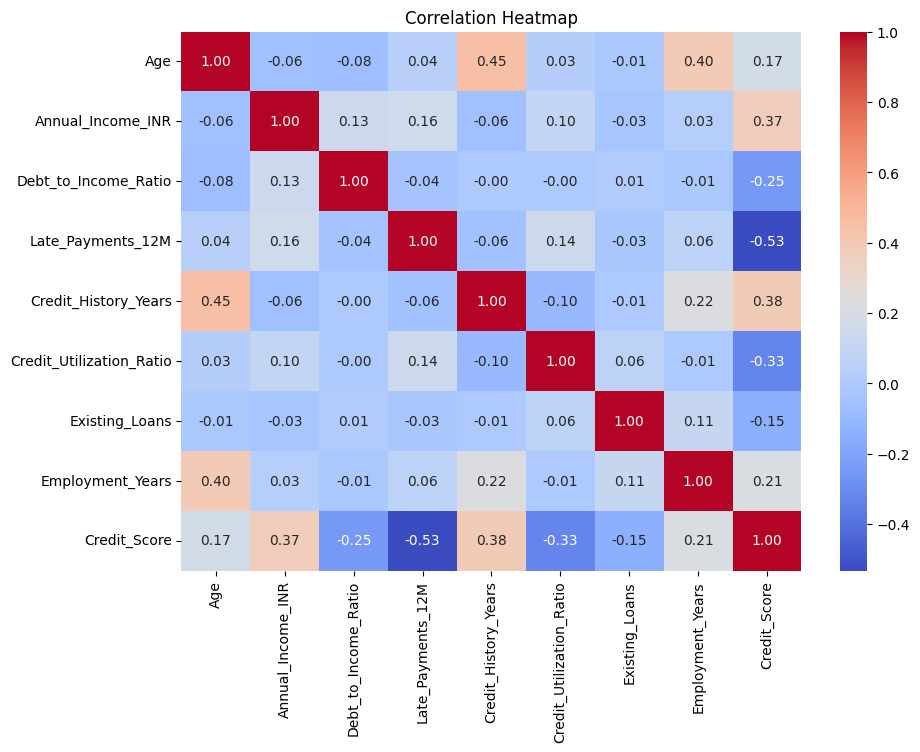

In [6]:
plt.figure(figsize=(10, 7))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Step 6: Feature and Target Selection

The independent variables are stored in **X**, while `Credit_Score` is selected as the dependent variable **y**.

* **X:** Predictor variables
* **y:** Credit_Score


In [7]:
X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]



## Step 7: Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used to build the model, while the testing set is used to evaluate its performance.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 8)
Testing data: (40, 8)


## Step 8: Model Training

A Multiple Linear Regression model is trained using the training dataset.

The model estimates the relationship between the credit score and multiple independent variables simultaneously.


In [27]:
model = LinearRegression()

model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.05, 0. , 0.09,...,-0.22,-4.39, 1.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Age','Annual_Income_INR','Debt_to_Income_Ratio',..., 'Credit_Utilization_Ratio','Existing_Loans','Employment_Years']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,332.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


## Step 9: Prediction

The trained model is used to predict credit scores for the observations in the testing dataset.


In [28]:
y_pred = model.predict(X_test)



## Step 10: Model Evaluation

The model is evaluated using four performance metrics:

* **MAE:** Measures the average absolute prediction error.
* **MSE:** Measures the average squared prediction error.
* **RMSE:** Represents the typical prediction error in credit-score points.
* **R²:** Measures the proportion of variation in credit score explained by the model.


In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 32.871051242758526
MSE : 1593.1161155220054
RMSE: 39.91385868995887
R²  : 0.6141916824416265


## Step 11: Coefficient Interpretation

The regression coefficients indicate how the predicted credit score changes when a predictor increases by one unit, while all other predictors are kept constant.

A positive coefficient indicates a positive relationship with the predicted credit score, while a negative coefficient indicates a negative relationship.


In [31]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [-4.63286159e-02  7.50167992e-05  9.13652892e-02 -1.63235016e+01
  3.03466627e+00 -2.16304866e-01 -4.39346985e+00  1.87385280e+00]
Intercept: 332.76170837525166


## Step 12: Actual vs Predicted Credit Scores

The actual credit scores are compared with the predicted credit scores using a scatter plot.

Points closer to the diagonal reference line indicate predictions closer to the actual values.


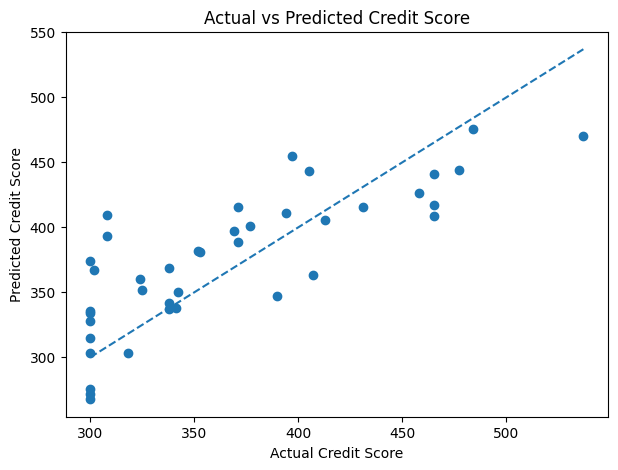

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Credit Score")
plt.ylabel("Predicted Credit Score")
plt.title("Actual vs Predicted Credit Score")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## Step 13: Residual Analysis

Residuals are calculated as:

**Residual = Actual Value − Predicted Value**

A residual plot is used to check whether the residuals are randomly distributed around zero. A random pattern generally supports the linearity and constant-variance assumptions.


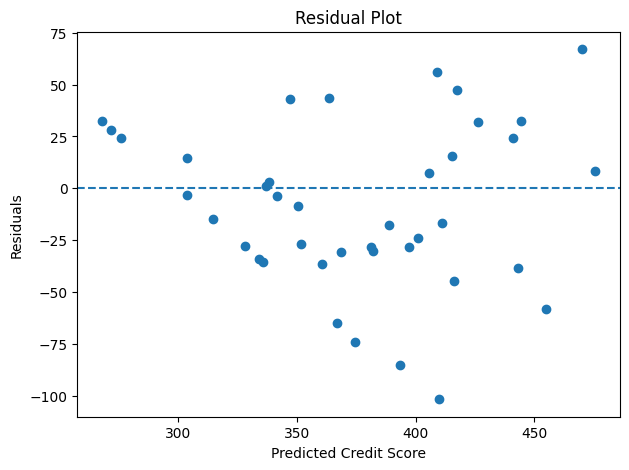

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Credit Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Step 14: Residual Distribution

The distribution of residuals is visualized using a histogram with a density curve to assess whether the residuals are approximately normally distributed.


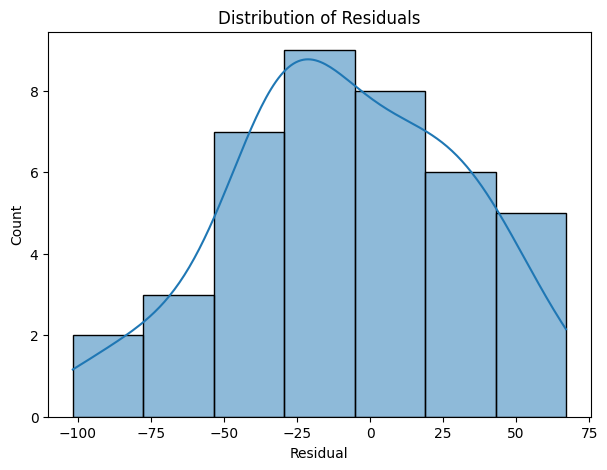

In [15]:
plt.figure(figsize=(7, 5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

## Extension: Standardized Coefficients

The features are standardized before fitting the regression model. Standardized coefficients allow the relative importance of predictors to be compared because all features are placed on the same scale.

The coefficients are arranged according to their absolute magnitude.


In [16]:
scaled_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

scaled_model.fit(X_train, y_train)

standardized_coefs = pd.Series(
    scaled_model.named_steps["linearregression"].coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

print("Standardized Coefficients:")
print(standardized_coefs)

Standardized Coefficients:
Late_Payments_12M          -40.410470
Annual_Income_INR           37.488791
Debt_to_Income_Ratio       -24.290407
Credit_History_Years        23.938458
Credit_Utilization_Ratio   -17.446882
Employment_Years            13.041168
Existing_Loans              -8.994244
Age                         -0.714367
dtype: float64


## Performance with Scaled Features

The regression model is trained using standardized features and evaluated using MAE, MSE, RMSE, and R².

For ordinary Multiple Linear Regression, scaling the input features generally does not change the predictions or evaluation metrics. It mainly changes the scale of the coefficients.


In [17]:
y_pred_scaled = scaled_model.predict(X_test)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("Scaled Model Performance")
print("------------------------")
print("MAE :", mae_scaled)
print("MSE :", mse_scaled)
print("RMSE:", rmse_scaled)
print("R²  :", r2_scaled)

Scaled Model Performance
------------------------
MAE : 22.129091316065796
MSE : 719.4408881508555
RMSE: 26.822395272437088
R²  : 0.8257714701798523


## Exercise 13: Change Test Size

The test size is changed from 20% to 25%. The resulting RMSE and R² values are compared with those obtained using the original 20% test size.


In [18]:
X_train25, X_test25, y_train25, y_test25 = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

model25 = LinearRegression()

model25.fit(X_train25, y_train25)

y_pred25 = model25.predict(X_test25)

rmse25 = np.sqrt(mean_squared_error(y_test25, y_pred25))
r2_25 = r2_score(y_test25, y_pred25)

print("Test Size = 0.25")
print("RMSE:", rmse25)
print("R²:", r2_25)

Test Size = 0.25
RMSE: 41.0974101955448
R²: 0.5552859437836057


## Exercise 14: Remove Age

The `Age` feature is removed and the regression model is retrained. The RMSE and R² values are compared to determine whether removing this feature affects model performance.


In [34]:
X1 = X.drop(columns=["Age"])

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y,
    test_size=0.20,
    random_state=42
)

model1= LinearRegression()

model1.fit(X_train1, y_train1)

y_pred1 = model1.predict(X_test1)

rmse_no_age = np.sqrt(mean_squared_error(y_test1, y_pred1))
r2_no_age = r2_score(y_test1, y_pred1)

print("Without Age:")
print("RMSE:", rmse_no_age)
print("R²:", r2_no_age)

Without Age:
RMSE: 39.88192872052009
R²: 0.614808707245861


## Step 15: Checking Regression Assumptions

The following six assumptions of Multiple Linear Regression are checked:

1. Linearity
2. Independence of Errors
3. Homoscedasticity
4. Normality of Residuals
5. Multicollinearity
6. Outliers and Influential Observations


### 1. Linearity

Linearity is checked using the residual plot. Residuals should be randomly scattered around zero without any clear pattern.


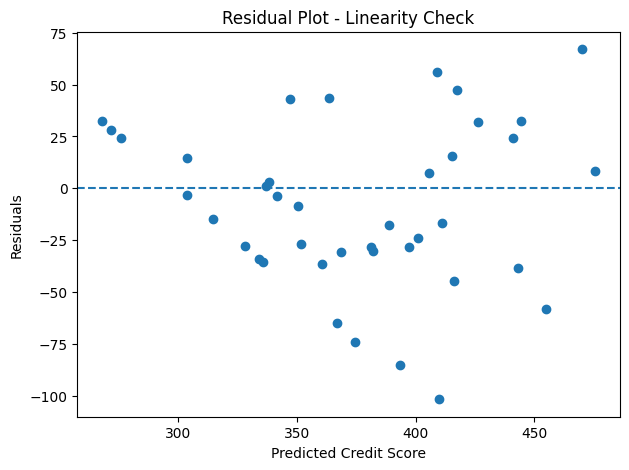

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Credit Score")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linearity Check")

plt.show()

### 2. Independence of Errors

The Durbin-Watson test is used to check whether the residuals are independent.


In [40]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)

print("Durbin-Watson:", dw)

Durbin-Watson: 2.0399825375620484


### 3. Homoscedasticity

The Breusch-Pagan test is used to check whether the residuals have constant variance.


In [42]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant/intercept column
X_test_bp = sm.add_constant(X_test)

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, X_test_bp)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("p-value:", bp_test[1])

Breusch-Pagan Test
LM Statistic: 11.4345092760977
p-value: 0.1782733738346864


### 4. Normality of Residuals

Normality is checked using a histogram and Q-Q plot. Residuals should approximately follow a normal distribution.


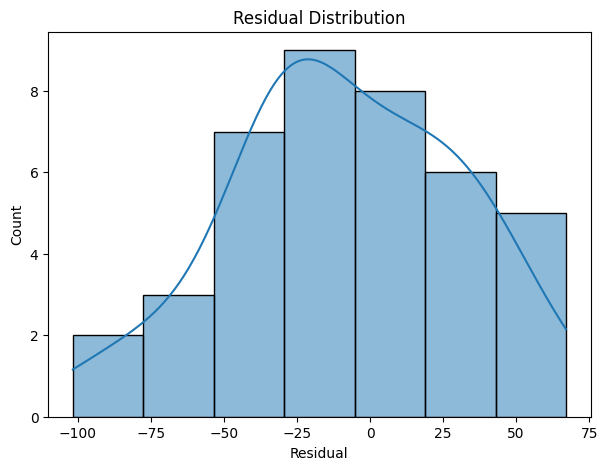

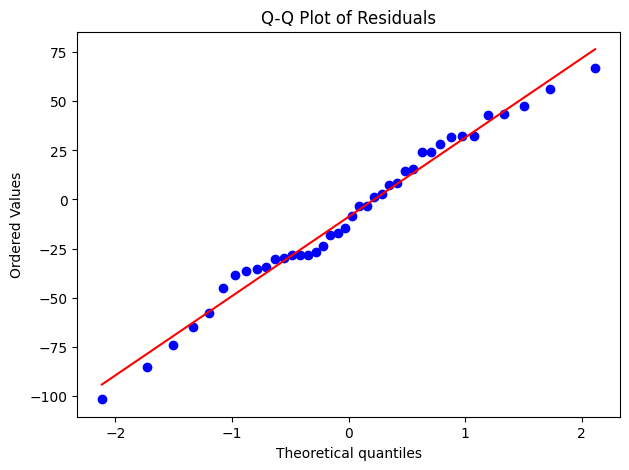

In [41]:
import scipy.stats as stats

plt.figure(figsize=(7, 5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.show()


plt.figure(figsize=(7, 5))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.show()

### 5. Multicollinearity

Variance Inflation Factor (VIF) is used to check multicollinearity among the independent variables.


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

display(vif_data)

,Feature,VIF
0,Age,12.125868
1,Annual_Income_INR,6.037938
2,Debt_to_Income_Ratio,4.927092
3,Late_Payments_12M,3.327805
4,Credit_History_Years,3.707407
5,Credit_Utilization_Ratio,4.405918
6,Existing_Loans,3.103387
7,Employment_Years,3.706353


### 4. Summary of Regression Assumptions

* **Linearity:** Checked using the residual plot.
* **Independence:** Checked using the Durbin-Watson test.
* **Homoscedasticity:** Checked using the residual plot and Breusch-Pagan test.
* **Normality:** Checked using the residual distribution histogram.
* **Multicollinearity:** Checked using VIF.


## Exercise 16: Largest Standardized Coefficients

The three predictors with the largest absolute standardized coefficients are identified. Their signs are interpreted as positive or negative relationships with the predicted credit score.


In [20]:
top_3 = standardized_coefs.head(3)

print("Three Largest Standardized Coefficients:")
print(top_3)

Three Largest Standardized Coefficients:
Late_Payments_12M      -40.410470
Annual_Income_INR       37.488791
Debt_to_Income_Ratio   -24.290407
dtype: float64


## Exercise 17: Income per Loan

A new derived feature, `Income_per_Loan`, is created using:

**Income_per_Loan = Annual_Income_INR / (Existing_Loans + 1)**

The model is retrained and its RMSE and R² are compared with the original model.


In [21]:
df["Income_per_Loan"] = (
    df["Annual_Income_INR"] / (df["Existing_Loans"] + 1)
)

X_new = df.drop(columns=["Credit_Score"])
y_new = df["Credit_Score"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.20,
    random_state=42
)

model_new = LinearRegression()

model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

rmse_new = np.sqrt(mean_squared_error(y_test_new, y_pred_new))
r2_new = r2_score(y_test_new, y_pred_new)

print("Model with Income_per_Loan")
print("RMSE:", rmse_new)
print("R²:", r2_new)

Model with Income_per_Loan
RMSE: 41.47950889425066
R²: 0.5833308304380165


## Exercise 18: Outlier Detection

Boxplots are used to inspect potential outliers in `Annual_Income_INR` and `Credit_Score`.


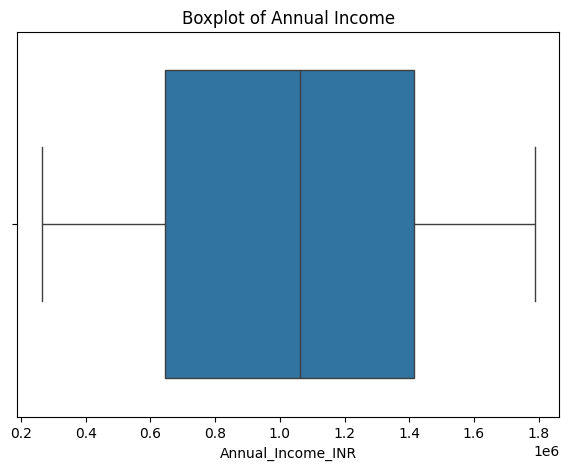

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(x=df["Annual_Income_INR"])

plt.title("Boxplot of Annual Income")
plt.show()

## Exercise 19: Logistic Regression

Logistic Regression is preferred for a `Default/No Default` target because:

1. The target contains two categorical classes.
2. Logistic Regression is designed for binary classification and estimates the probability of belonging to a class.


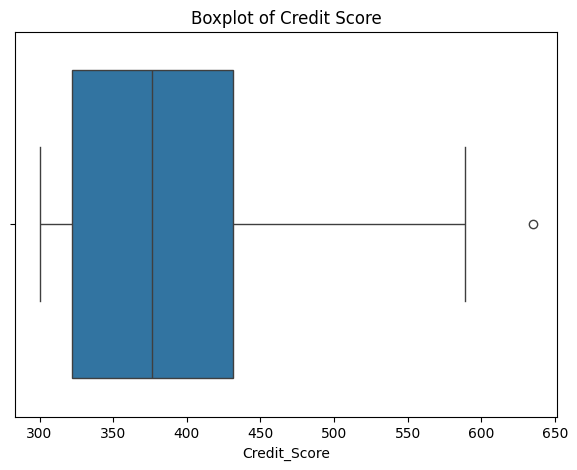

In [23]:
plt.figure(figsize=(7, 5))

sns.boxplot(x=df["Credit_Score"])

plt.title("Boxplot of Credit Score")
plt.show()

## New Applicant Prediction

The trained Multiple Linear Regression model is used to estimate the credit score of a new applicant based on their demographic and financial attributes.


In [25]:
new_applicant = pd.DataFrame({
    "Age": [30],
    "Annual_Income_INR": [800000],
    "Debt_to_Income_Ratio": [0.30],
    "Late_Payments_12M": [1],
    "Credit_History_Years": [6],
    "Credit_Utilization_Ratio": [0.25],
    "Existing_Loans": [2],
    "Employment_Years": [5]
})

predicted_score = model.predict(new_applicant)

print("Predicted Credit Score:", predicted_score[0])

Predicted Credit Score: 393.8254429191026


## Result

A Multiple Linear Regression model was successfully developed to predict the credit score of applicants using demographic and financial attributes. The model was evaluated using MAE, MSE, RMSE, and R².



In [26]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Obtained Value": [mae, mse, rmse, r2]
})

display(results)

,Metric,Obtained Value
0,MAE,32.871051
1,MSE,1593.116116
2,RMSE,39.913859
3,R²,0.614192


## Conclusion

The experiment demonstrated the complete workflow of a regression problem, including data preprocessing, feature selection, model training, prediction, evaluation, coefficient interpretation, residual analysis, and standardized feature analysis.